In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pyproffit

%matplotlib inline

In [15]:
fits_file = 'grid_halo_TNG100-1_99_111.fits'

In [16]:
with fits.open(fits_file) as hdul:
    hdul.info()
    header = hdul[0].header
    data   = hdul[0].data.copy()

print(repr(header))
print('\nArray shape:', data.shape, '| dtype:', data.dtype)

Filename: grid_halo_TNG100-1_99_111.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   (800, 800)   float32   
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  800                                                  
NAXIS2  =                  800                                                  
SIM     = 'TNG100-1'           / IllustrisTNG simulation                        
SNAP    =                   99 / Snapshot number                                
HALO_ID =                  111 / Subhalo/halo ID                                
TYPE    = 'halo    '           / Object type                                    
FILL_VAL=                 99.0 / Sentinel value for empty pixels                
BUNIT   = 'log SB  ' 

In [17]:
# Fill value 99.0 = empty pixels in the IllustrisTNG halo visualizer grid
FILL   = 99.0
masked = np.ma.masked_where(data >= FILL, data)

print(f'Valid pixels : {masked.count():,} / {data.size:,}')
print(f'Value range  : {masked.min():.3f}  to  {masked.max():.3f}')


Valid pixels : 18,048 / 640,000
Value range  : 18.481  to  30.606


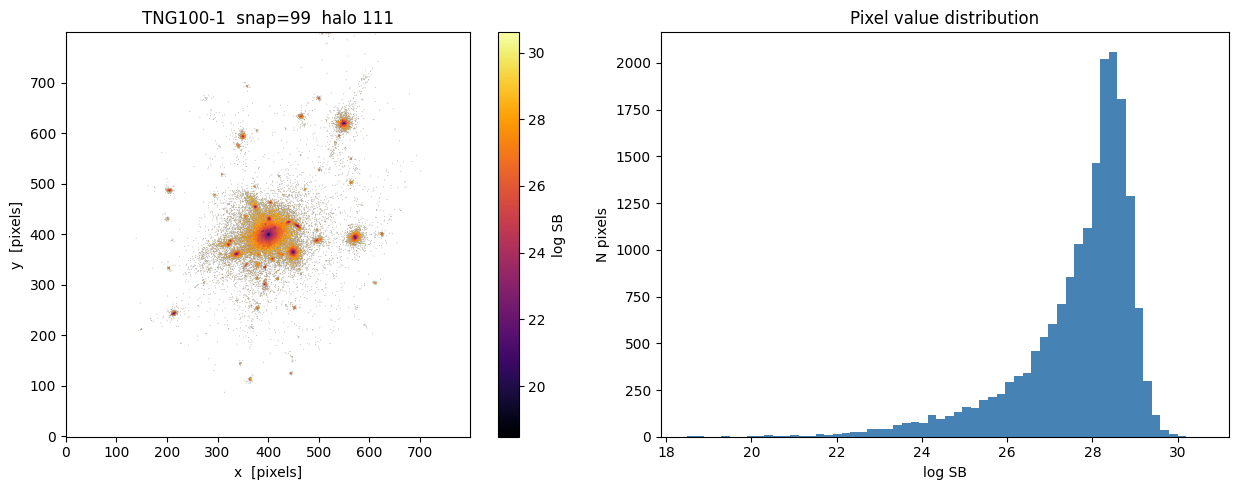

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(masked, origin='lower', cmap='inferno')
axes[0].set_title(f"{header['SIM']}  snap={header['SNAP']}  halo {header['HALO_ID']}")
axes[0].set_xlabel('x  [pixels]')
axes[0].set_ylabel('y  [pixels]')
plt.colorbar(im, ax=axes[0], label=header['BUNIT'])

axes[1].hist(masked.compressed(), bins=60, color='steelblue', edgecolor='none')
axes[1].set_xlabel(header['BUNIT'])
axes[1].set_ylabel('N pixels')
axes[1].set_title('Pixel value distribution')

plt.tight_layout()
plt.show()

In [19]:
pixel_data  = masked.compressed()

In [27]:
prof = pyproffit.Profile(pixel_data, maxrad=100, binsize=20, center_choice = "centroid")

Computing centroid and ellipse parameters using principal component analysis


/opt/anaconda3/envs/astro133/lib/python3.13/site-packages/pyproffit/profextract.py:1095: SyntaxWarning: invalid escape sequence '\m'
  :param psffile: Path to file containing an image of the PSF. The pixel size \must be equal to the pixel size of the image.
/opt/anaconda3/envs/astro133/lib/python3.13/site-packages/pyproffit/profextract.py:1419: SyntaxWarning: invalid escape sequence '\S'
  plt.ylabel('$\Sigma_{X}$', fontsize=fontsize)
/opt/anaconda3/envs/astro133/lib/python3.13/site-packages/pyproffit/profextract.py:1473: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$\chi$', fontsize=fontsize)


AttributeError: 'numpy.ndarray' object has no attribute 'filth'